# pycubetools — Quick-start Notebook

This notebook demonstrates the full `pycubetools` API against two real `.cubex` profiles of the **TeaLeaf** HPC benchmark:

| File | Parallelism |
|---|---|
| `data/summary.cubex` | 16 MPI ranks × 8 OMP threads (Scalasca summary) |
| `data/trace.cubex` | 8 MPI ranks × 8 OMP threads (Scalasca trace) |

Topics covered:
1. Configuration and loading
2. Experiment metadata (metrics, system, call tree)
3. Call-tree profiling (`calltree`)
4. Per-routine statistics (`stat`)
5. Raw metric dump and thread-imbalance analysis (`dump`)
6. Algebra: differencing two profiles (`diff`)

## 1  Setup

`pycubetools` resolves CubeLib binaries in this order (highest to lowest priority):

1. An explicit `configure(install_dir=…)` call in the session
2. The `CUBE_INSTALL_DIR` environment variable
3. `~/.config/pycubetools/config.toml`
4. `shutil.which` PATH lookup

Edit `CUBE_INSTALL_DIR` in the cell below if CubeLib is not already on your PATH or the env variable is not set.

In [1]:
import os
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

import pycubetools
from pycubetools import CubeExperiment, SystemDimension

# ── Set this to your CubeLib install prefix if CubeLib is not on PATH ────────
# Leave as None when CUBE_INSTALL_DIR env var is set or binaries are on PATH.
CUBE_INSTALL_DIR: str | None = None  # e.g. "/opt/cube" or str(Path.home() / "software/cube")
# ─────────────────────────────────────────────────────────────────────────────

if CUBE_INSTALL_DIR is not None:
    pycubetools.configure(install_dir=CUBE_INSTALL_DIR)
elif "CUBE_INSTALL_DIR" not in os.environ and shutil.which("cube_info") is None:
    raise RuntimeError(
        "CubeLib binaries not found on PATH and CUBE_INSTALL_DIR is not set.\n"
        "Either set the CUBE_INSTALL_DIR environment variable before starting "
        "Jupyter, or assign your install prefix to the CUBE_INSTALL_DIR "
        "variable at the top of this cell."
    )

print(f"pycubetools ready  ·  polars {pl.__version__}")

pycubetools ready  ·  polars 1.40.1


## 2  Loading experiments

`CubeExperiment` wraps a `.cubex` file. No data is read until you actually call a method, so construction is always fast. Use it as a context manager when you want automatic cleanup of temporary files produced by algebra operations.

In [2]:
summary = CubeExperiment("data/summary.cubex")
trace   = CubeExperiment("data/trace.cubex")

print(summary)
print(trace)

CubeExperiment('data/summary.cubex')
CubeExperiment('data/trace.cubex')


## 3  Experiment metadata

### 3.1  Basic info

`info_basic()` calls `cube_info -b` and returns node / process / wallclock data as a plain dict.

In [3]:
for label, exp in (("summary", summary), ("trace", trace)):
    meta = exp.info_basic()
    print(
        f"{label:8s}  nodes={meta['nodes']}  "
        f"procs={meta['processes']}  "
        f"wallclock={meta['wallclock_time']:.2f} s"
    )

summary   nodes=2  procs=16  wallclock=49.62 s


trace     nodes=2  procs=8  wallclock=81.66 s


### 3.2  Metric tree

`metric_tree` is a cached property populated by pyCubexR (no subprocess). It lists every metric stored in the file.

In [4]:
summary.metric_tree.select(["name", "display_name", "uom", "description"])

name,display_name,uom,description
str,str,str,str
"""time""","""Time""","""sec""","""Total CPU allocation time (inc…"
"""execution""","""Execution""","""sec""","""Execution time (does not inclu…"
"""comp""","""Computation""","""sec""","""Time spent on computation"""
"""mpi""","""MPI""","""sec""","""Time spent in MPI calls"""
"""mpi_management""","""Management""","""sec""","""Time spent in MPI management o…"
…,…,…,…
"""imbalance_below_singularity""","""Singularity""","""sec""","""Computational load imbalance h…"
"""min_time""","""Minimum Inclusive Time""","""sec""","""Minimum inclusive CPU allocati…"
"""max_time""","""Maximum Inclusive Time""","""sec""","""Maximum inclusive CPU allocati…"


### 3.3  System tree

`system_tree` lists every thread location: machine → node → MPI rank → OMP thread.

In [5]:
sys = summary.system_tree
print(f"{len(sys)} thread locations")
sys.head(10)

128 thread locations


machine,node,process,thread
str,str,str,str
"""machine Linux""","""node jrc0148""","""MPI Rank 0""","""Master thread"""
"""machine Linux""","""node jrc0148""","""MPI Rank 0""","""OMP thread 1"""
"""machine Linux""","""node jrc0148""","""MPI Rank 0""","""OMP thread 2"""
"""machine Linux""","""node jrc0148""","""MPI Rank 0""","""OMP thread 3"""
"""machine Linux""","""node jrc0148""","""MPI Rank 0""","""OMP thread 4"""
"""machine Linux""","""node jrc0148""","""MPI Rank 0""","""OMP thread 5"""
"""machine Linux""","""node jrc0148""","""MPI Rank 0""","""OMP thread 6"""
"""machine Linux""","""node jrc0148""","""MPI Rank 0""","""OMP thread 7"""
"""machine Linux""","""node jrc0148""","""MPI Rank 1""","""Master thread"""


In [6]:
# Summarise layout: unique nodes and ranks
(
    sys
    .group_by(["machine", "node"])
    .agg(pl.col("process").n_unique().alias("mpi_ranks"),
         pl.col("thread").n_unique().alias("omp_threads"))
    .sort("node")
)

machine,node,mpi_ranks,omp_threads
str,str,u32,u32
"""machine Linux""","""node jrc0148""",8,8
"""machine Linux""","""node jrc0149""",8,8


### 3.4  Call-node tree

`cnode_tree` lists every node in the static call tree with its parent and depth.

In [7]:
ct_nodes = summary.cnode_tree
print(f"{len(ct_nodes)} call-tree nodes, max depth {ct_nodes['depth'].max()}")
ct_nodes.head(8)

329 call-tree nodes, max depth 10


cnode_id,region_name,file,line,parent_id,depth
i64,str,str,i64,i64,i64
0,"""tea_leaf""","""""",0,null,0
1,"""tea_leaf""","""/p/project1/ccstpa/aschburgos1…",35,0,1
2,"""tea_module::tea_init_comms""","""/p/project1/ccstpa/aschburgos1…",70,1,2
3,"""MPI_Init""","""MPI""",0,2,3
4,"""MPI_Comm_rank""","""MPI""",0,2,3
5,"""MPI_Comm_size""","""MPI""",0,2,3
6,"""!$omp parallel @tea_leaf.f90:4…","""/p/project1/ccstpa/aschburgos1…",45,1,2
7,"""!$omp implicit barrier @tea_le…","""/p/project1/ccstpa/aschburgos1…",64,6,3


## 4  Call-tree profiling

`calltree()` invokes `cube_calltree` and returns a DataFrame with inclusive or exclusive metric values per call-tree node.

Columns: `cnode_id`, `name`, `callpath`, `value`, `pct`, `depth`.

In [8]:
# Inclusive time (default): each node includes time spent in callees
ct_incl = summary.calltree(metric="time", inclusive=True)

# Exclusive time: time charged to this node only (self time)
ct_excl = summary.calltree(metric="time", inclusive=False)

print(f"Inclusive: {len(ct_incl)} rows   Exclusive: {len(ct_excl)} rows")
ct_excl.head(6)

Inclusive: 329 rows   Exclusive: 329 rows


cnode_id,name,callpath,value,pct,depth
i64,str,str,f64,f64,i64
0,"""tea_leaf""","""USR:/tea_leaf""",0.0117698,0.0002133,0
1,"""tea_leaf""","""USR:/tea_leaf/tea_leaf""",0.116126,0.002105,1
2,"""tea_module::tea_init_comms""","""USR:/tea_leaf/tea_leaf/tea_mod…",0.0111515,0.0002021,2
3,"""MPI_Init""","""USR:/tea_leaf/tea_leaf/tea_mod…",110.566,2.004,3
4,"""MPI_Comm_rank""","""USR:/tea_leaf/tea_leaf/tea_mod…",0.001581,0.000029,3
5,"""MPI_Comm_size""","""USR:/tea_leaf/tea_leaf/tea_mod…",0.000151,0.000003,3


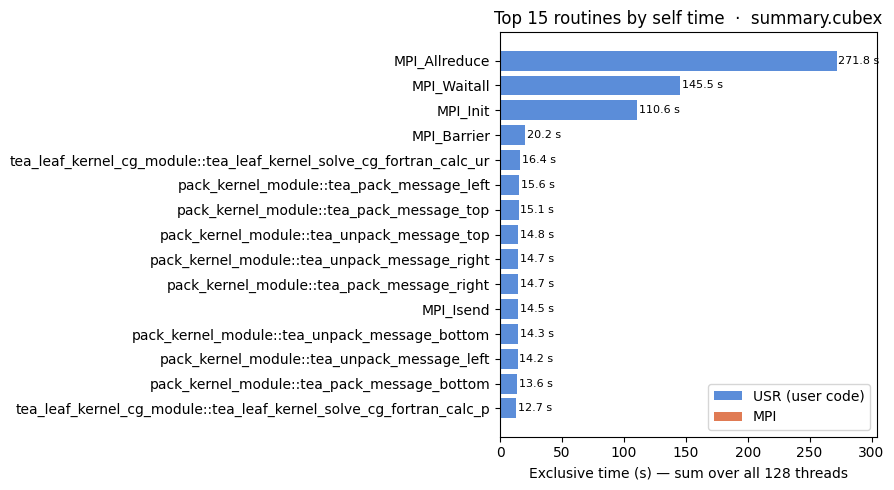

In [9]:
# Top 15 routines by exclusive time (self time), USR and MPI paths only
def prefix_color(callpath: str) -> str:
    if callpath.startswith("MPI:"):
        return "#e07b54"
    if callpath.startswith("USR:"):
        return "#5b8dd9"
    return "#aaaaaa"

top = (
    ct_excl
    .filter(
        pl.col("callpath").str.starts_with("USR:") |
        pl.col("callpath").str.starts_with("MPI:")
    )
    .sort("value", descending=True)
    .head(15)
    .reverse()   # so largest is at the top of a horizontal bar chart
)

labels = top["name"].to_list()
values = top["value"].to_list()
colors = [prefix_color(cp) for cp in top["callpath"].to_list()]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(labels, values, color=colors, edgecolor="none")
ax.set_xlabel("Exclusive time (s) — sum over all 128 threads")
ax.set_title("Top 15 routines by self time  ·  summary.cubex")

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#5b8dd9", label="USR (user code)"),
    Patch(facecolor="#e07b54", label="MPI"),
], loc="lower right")

ax.set_xlim(0, max(values) * 1.12)
for bar, v in zip(bars, values):
    ax.text(v + max(values) * 0.005, bar.get_y() + bar.get_height() / 2,
            f"{v:.1f} s", va="center", fontsize=8)

plt.tight_layout()
plt.show()

## 5  Per-routine statistics

`stat()` calls `cube_stat -%` and returns per-thread statistics (count, sum, mean, variance, min, max) for each routine. You can request multiple metrics at once.

In [10]:
stats = summary.stat(metrics=("time", "mpi"))
stats

metric,routine,count,sum,mean,variance,minimum,maximum
str,str,i64,f64,f64,f64,f64,f64
"""time""","""INCL(tea_leaf)""",128,5516.71,43.0993,0.041576,42.8287,43.4112
"""time""","""EXCL(tea_leaf)""",128,0.0117698,0.000092,2.5848e-10,0.00008,0.000137
"""time""","""INCL(tea_leaf)""",128,5516.69,43.0992,0.0415756,42.8286,43.4111
"""mpi""","""INCL(tea_leaf)""",128,72.8781,0.56936,2.35106,0.0,5.73601
"""mpi""","""EXCL(tea_leaf)""",128,0.0,0.0,0.0,0.0,0.0
"""mpi""","""INCL(tea_leaf)""",128,72.8781,0.56936,2.35106,0.0,5.73601


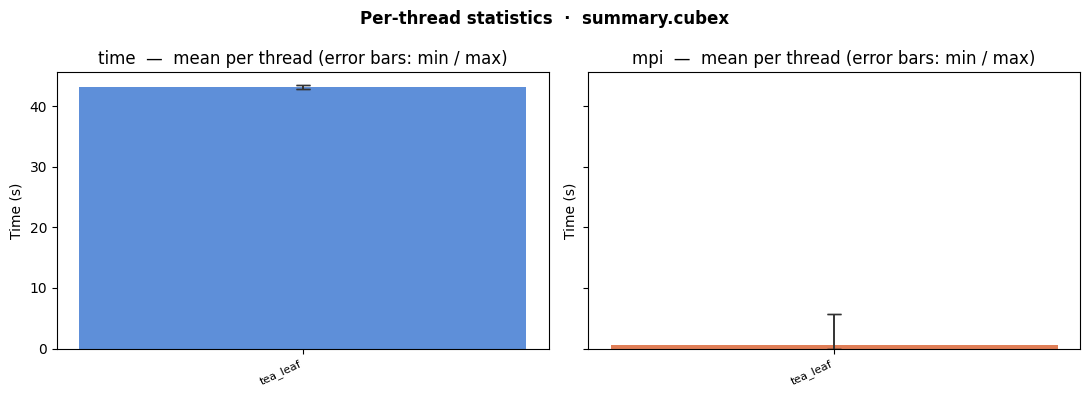

In [11]:
# Merge stat data with calltree to get per-routine self-time ranking
# then visualise mean ± (min, max) per metric for each top routine

# Keep INCL rows (inclusive) and clean routine names
stats_incl = (
    stats
    .filter(pl.col("routine").str.starts_with("INCL("))
    .with_columns(
        pl.col("routine").str.strip_prefix("INCL(").str.strip_suffix(")").alias("routine")
    )
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

metric_colors = {"time": "#5b8dd9", "mpi": "#e07b54"}

for ax, metric in zip(axes, ("time", "mpi")):
    rows = stats_incl.filter(pl.col("metric") == metric)
    routines = rows["routine"].to_list()
    means    = rows["mean"].to_list()
    mins     = rows["minimum"].to_list()
    maxs     = rows["maximum"].to_list()
    yerr_lo  = [m - lo for m, lo in zip(means, mins)]
    yerr_hi  = [hi - m  for m, hi in zip(means, maxs)]

    ax.bar(routines, means, color=metric_colors[metric],
           alpha=0.85, edgecolor="none")
    ax.errorbar(routines, means,
                yerr=[yerr_lo, yerr_hi],
                fmt="none", color="#333333", capsize=5, linewidth=1.2)
    ax.set_title(f"{metric}  —  mean per thread (error bars: min / max)")
    ax.set_ylabel("Time (s)")
    plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)

fig.suptitle("Per-thread statistics  ·  summary.cubex", fontweight="bold")
plt.tight_layout()
plt.show()

## 6  Call-tree view with metric values

`info()` calls `cube_info -m <metric>` and returns the call tree with a single metric value per node. This is useful for a quick text-based tree view.

In [12]:
tree_df = summary.info(metric="time")

# Print the top 20 nodes as an indented tree
print(f"{'Value':>12}  {'%':>7}  Routine")
print("-" * 70)
for row in tree_df.head(20).iter_rows(named=True):
    indent = "  " * row["depth"]
    total  = tree_df["value"][0]
    pct    = row["value"] / total * 100 if total else 0.0
    print(f"{row['value']:12.4f}  {pct:6.2f}%  {indent}{row['name']}")

       Value        %  Routine
----------------------------------------------------------------------
   5516.7053  100.00%  tea_leaf
   5516.6935  100.00%    tea_leaf
    110.5789    2.00%      tea_module::tea_init_comms
    110.5661    2.00%        MPI_Init
      0.0016    0.00%        MPI_Comm_rank
      0.0002    0.00%        MPI_Comm_size
      0.0193    0.00%      !$omp parallel @tea_leaf.f90:45
      0.0099    0.00%        !$omp implicit barrier @tea_leaf.f90:64
     26.0506    0.47%      initialise
      0.0079    0.00%        get_unit
      0.0006    0.00%        !$omp parallel @initialise.f90:48
      0.0004    0.00%          !$omp implicit barrier @initialise.f90:61
     20.1557    0.37%        tea_module::tea_barrier
     20.1533    0.37%          MPI_Barrier
      0.0000    0.00%        parse_module::parse_init
      0.0011    0.00%        parse_module::parse_getline
      0.2234    0.00%        read_input
      0.0016    0.00%          parse_module::parse_init
      0.193

## 7  Raw metric dump and thread-imbalance analysis

`dump()` calls `cube_dump -s csv2` and returns a long-format DataFrame with one row per (cnode, thread, metric). This gives you access to individual thread values — ideal for imbalance analysis.

In [13]:
# Aggregated mode (default, threads='aggr'): one row per cnode, summed over threads
dump_aggr = summary.dump(metrics=("time", "mpi"), cnodes="all", threads="aggr")
print(f"Aggregated dump: {dump_aggr.shape}")
dump_aggr.head(6)

Aggregated dump: (658, 4)


cnode_id,thread_id,metric,value
i64,i32,str,f64
0,-1,"""mpi""",0.0
1,-1,"""mpi""",0.0
2,-1,"""mpi""",0.0
3,-1,"""mpi""",13.8208
4,-1,"""mpi""",0.000198
5,-1,"""mpi""",0.000019


In [14]:
# Per-thread dump for the 8 threads of MPI rank 0 (thread IDs 0–7)
dump_t = summary.dump(metrics=("time",), cnodes="all", threads="0-7")
print(f"Per-thread dump: {dump_t.shape}")
dump_t.head(6)

Per-thread dump: (2632, 4)


cnode_id,thread_id,metric,value
i64,i64,str,f64
0,0,"""time""",0.000085
0,1,"""time""",0.000085
0,2,"""time""",0.000085
0,3,"""time""",0.000085
0,4,"""time""",0.000085
0,5,"""time""",0.000085


In [15]:
# Find the most time-consuming call-tree node (by aggregated exclusive time)
top_cnode_id = (
    dump_aggr
    .filter(pl.col("metric") == "time")
    .sort("value", descending=True)
    .head(1)["cnode_id"]
    .item()
)
top_name = (
    summary.cnode_tree
    .filter(pl.col("cnode_id") == top_cnode_id)["region_name"]
    .item()
)
print(f"Hottest cnode: id={top_cnode_id}  name={top_name!r}")

# Per-thread time for that cnode across the 8 threads of rank 0
thread_vals = (
    dump_t
    .filter((pl.col("cnode_id") == top_cnode_id) & (pl.col("metric") == "time"))
    .sort("thread_id")
)
thread_vals

Hottest cnode: id=222  name='!$omp do @tea_leaf_cg.f90:187'


cnode_id,thread_id,metric,value
i64,i64,str,f64
222,0,"""time""",18.5073
222,1,"""time""",17.8431
222,2,"""time""",18.2012
222,3,"""time""",18.0373
222,4,"""time""",18.3947
222,5,"""time""",18.0276
222,6,"""time""",18.48
222,7,"""time""",18.0179


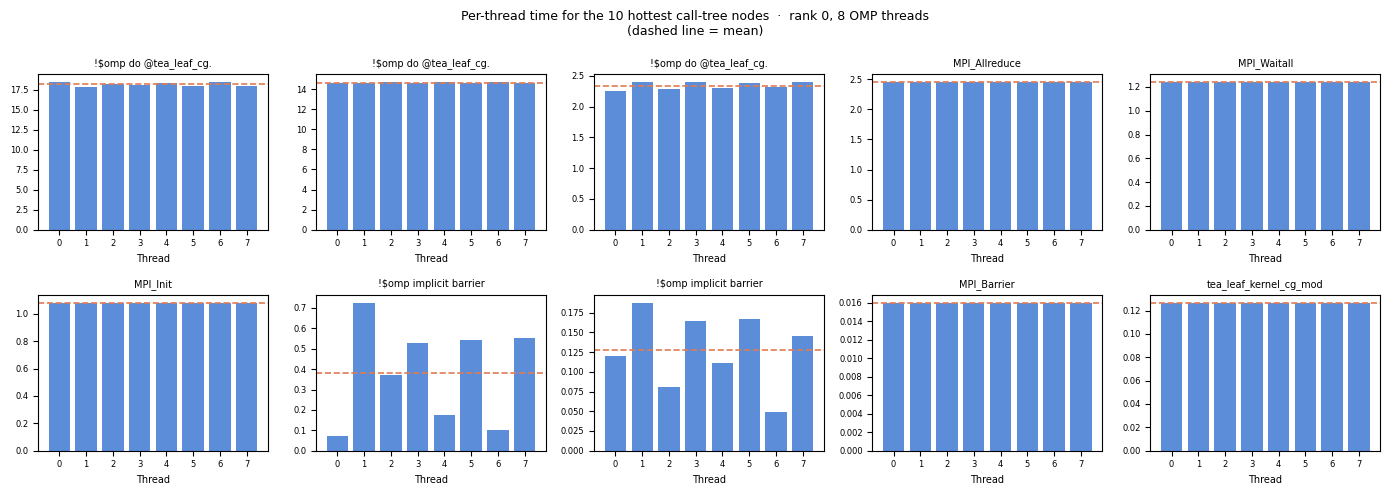

In [16]:
# Thread imbalance chart: per-thread time for the top-10 hottest cnodes
hot_ids = (
    dump_aggr
    .filter(pl.col("metric") == "time")
    .sort("value", descending=True)
    .head(10)["cnode_id"]
    .to_list()
)

hot_names = {
    row["cnode_id"]: row["region_name"]
    for row in summary.cnode_tree
    .filter(pl.col("cnode_id").is_in(hot_ids))
    .iter_rows(named=True)
}

fig, axes = plt.subplots(2, 5, figsize=(14, 5), sharey=False)

for ax, cnode_id in zip(axes.flat, hot_ids):
    rows = (
        dump_t
        .filter((pl.col("cnode_id") == cnode_id) & (pl.col("metric") == "time"))
        .sort("thread_id")
    )
    if rows.is_empty():
        ax.set_visible(False)
        continue
    tids = rows["thread_id"].to_list()
    vals = rows["value"].to_list()
    mean_v = sum(vals) / len(vals) if vals else 0
    ax.bar(tids, vals, color="#5b8dd9", edgecolor="none")
    ax.axhline(mean_v, color="#e07b54", linewidth=1.2, linestyle="--")
    ax.set_title(hot_names.get(cnode_id, str(cnode_id))[:22], fontsize=7)
    ax.set_xlabel("Thread", fontsize=7)
    ax.tick_params(labelsize=6)

fig.suptitle(
    "Per-thread time for the 10 hottest call-tree nodes  ·  rank 0, 8 OMP threads\n"
    "(dashed line = mean)",
    fontsize=9,
)
plt.tight_layout()
plt.show()

## 8  Algebra: differencing two experiments

`diff()` calls `cube_diff` to subtract one experiment from another and returns a new `CubeExperiment` wrapping the result. When the system dimensions don't match (different number of MPI ranks here), pass `system_dim=SystemDimension.COLLAPSE` to aggregate per-rank data first.

The result object owns its temporary file and cleans up automatically when used as a context manager.

In [17]:
# summary has 16 MPI ranks, trace has 8 — collapse both before subtracting
with summary.diff(trace, system_dim=SystemDimension.COLLAPSE) as delta:
    print("Diff result:", delta)
    diff_ct = delta.calltree(metric="time", inclusive=True)

print(f"\n{len(diff_ct)} nodes in the diff call tree")
diff_ct.head(6)

Diff result: CubeExperiment('/var/folders/rv/3k_mcl096c72dl9x81zwxg_w0000gn/T/tmp6d41bsmi/13dbe3caf502419f8cc2d3357a3e7325.cubex')

329 nodes in the diff call tree


cnode_id,name,callpath,value,pct,depth
i64,str,str,f64,f64,i64
0,"""tea_leaf""","""USR:/tea_leaf""",-3269.78,100.0,0
1,"""tea_leaf""","""USR:/tea_leaf/tea_leaf""",-8786.45,268.72,1
2,"""tea_module::tea_init_comms""","""USR:/tea_leaf/tea_leaf/tea_mod…",-75.5439,2.31,2
3,"""MPI_Init""","""USR:/tea_leaf/tea_leaf/tea_mod…",-75.5288,2.31,3
4,"""MPI_Comm_rank""","""USR:/tea_leaf/tea_leaf/tea_mod…",-0.000246,0.000008,3
5,"""MPI_Comm_size""","""USR:/tea_leaf/tea_leaf/tea_mod…",-0.000138,0.000004,3


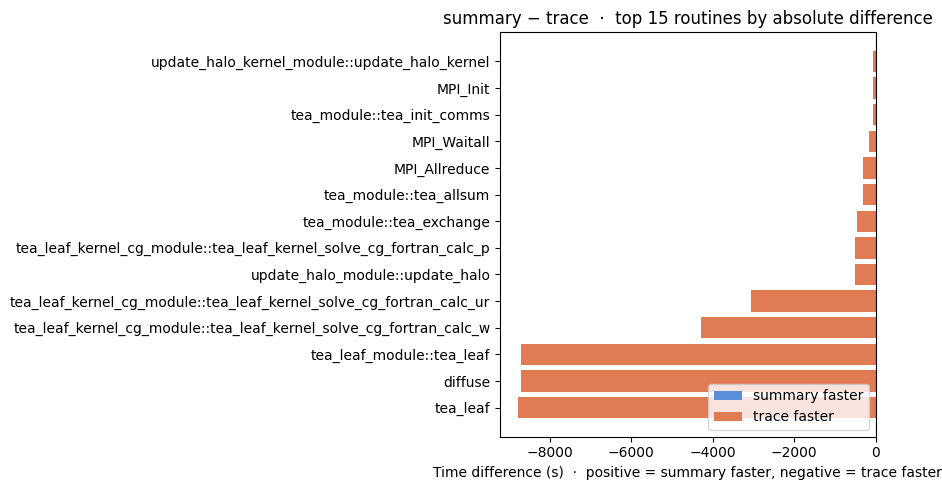

In [18]:
# Visualise: routines where summary was faster (positive diff) vs slower (negative diff)
sig = (
    diff_ct
    .filter(
        pl.col("callpath").str.starts_with("USR:") |
        pl.col("callpath").str.starts_with("MPI:")
    )
    .with_columns(pl.col("value").abs().alias("abs_val"))
    .sort("abs_val", descending=True)
    .head(15)
    .sort("value")
)

labels = sig["name"].to_list()
values = sig["value"].to_list()
colors = ["#e07b54" if v < 0 else "#5b8dd9" for v in values]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(labels, values, color=colors, edgecolor="none")
ax.axvline(0, color="#333333", linewidth=0.8)
ax.set_xlabel("Time difference (s)  ·  positive = summary faster, negative = trace faster")
ax.set_title("summary − trace  ·  top 15 routines by absolute difference")

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#5b8dd9", label="summary faster"),
    Patch(facecolor="#e07b54", label="trace faster"),
], loc="lower right")

plt.tight_layout()
plt.show()

## 9  Context manager and cleanup

Algebra methods (`diff`, `merge`, `mean`) write a new `.cubex` file. When `output_dir` is `None` (the default), a temporary directory is used and the file is deleted when the result object is garbage-collected or the context manager exits.

Pass an explicit `output_dir` to keep the file on disk:

```python
with summary.diff(trace, system_dim=SystemDimension.COLLAPSE,
                  output_dir="/scratch/results") as delta:
    df = delta.calltree()
# file persists at /scratch/results/<uuid>.cubex
```

The `CubeExperiment` returned by the with-block is still valid; only the automatic cleanup is suppressed when `output_dir` is provided.

---

## Summary of the API

| Method / property | Underlying tool | Returns |
|---|---|---|
| `metric_tree` | pyCubexR (no subprocess) | `pl.DataFrame` |
| `system_tree` | pyCubexR | `pl.DataFrame` |
| `cnode_tree` | pyCubexR | `pl.DataFrame` |
| `info_basic()` | `cube_info -b` | `dict` |
| `info(metric)` | `cube_info -m metric` | `pl.DataFrame` |
| `calltree(metric, inclusive)` | `cube_calltree -a -c -p` | `pl.DataFrame` |
| `stat(metrics, …)` | `cube_stat -%` | `pl.DataFrame` |
| `dump(metrics, cnodes, threads)` | `cube_dump -s csv2` | `pl.DataFrame` |
| `diff(other, system_dim)` | `cube_diff` | `CubeExperiment` |
| `merge(*exps, system_dim)` | `cube_merge` | `CubeExperiment` |
| `mean(*exps, system_dim)` | `cube_mean` | `CubeExperiment` |
| `cmp(other)` | `cube_cmp` | `CompareResult` |